In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import pyvisa as visa
import time

kHz = 1e3
MHz = 1e6
GHz = 1e9

In [32]:
def setupXaxis(f_center, f_span, n_points, active_channel=1):
    
    kna.write(f":SENS{active_channel}:FREQ:CENT {f_center}")
    time.sleep(0.2)
    kna.write(f":SENS{active_channel}:FREQ:SPAN {f_span}")
    time.sleep(0.2)
    kna.write(f":SENS{active_channel}:SWE:POIN {n_points}")
    time.sleep(0.2)
#     kna.write(f":SENS{active_channel}:SWE:TYPE LIN")
#     time.sleep(1)

    x_array = np.linspace(f_center - f_span/2, f_center + f_span/2, n_points)
    
    return x_array


def setupMeasurement(s_ij = "S21", meas_format = "COMP", active_channel=1):
    
    # Supply all arguments in correct units
    
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:PAR {s_ij};")
    time.sleep(0.5)
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:FORM {meas_format};")
    time.sleep(0.5)


def setupAveraging(n_avgs, IF_bw):
    
    kna.write(f":SENS{active_channel}:BWID {IF_bw}")
    time.sleep(0.5)
    kna.write(f":SENS{active_channel}:AVER ON")
    time.sleep(0.5)
    kna.write(f":SENS{active_channel}:AVER:COUN {n_avgs}")
    time.sleep(0.5)
    
def setPower_getRealImag(power_dBm, wait_time, active_channel=1):
    
    kna.write(f":SOUR{active_channel}:POW {power_dBm}")
    time.sleep(wait_time)
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
    ydata_str = kna.read()
    ydata_temp = ydata_str.split(",")
    y_data = np.array([float(d) for d in ydata_temp])
    y_data = y_data.reshape(n_points, 2)
    y_data = y_data.transpose()
    
    real, imag = y_data
    
    return real, imag

# def setPower(power_dBm, wait_time, active_channel=1):
    
#     kna.write(f":SOUR{active_channel}:POW {power_dBm}")
#     time.sleep(0.5)
#     power=kna.read()
    
#     return real, imag

def save_data(data, fname, path = r"D:\BlueFors Fridge setup\Lossy filters\Low lossy\\"):
    
    data = np.transpose(data)
    
    np.savetxt(path + fname, data)
    
def getRealImag(active_channel=1):
    
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
    ydata_str = kna.read()
    ydata_temp = ydata_str.split(",")
    y_data = np.array([float(d) for d in ydata_temp])
    y_data = y_data.reshape(n_points, 2)
    y_data = y_data.transpose()
    
    real, imag = y_data
    
    return real, imag

In [33]:
ip = "TCPIP::192.168.0.27"
# ip = "TCPIP0::DESKTOP-S092ETA::hislip_PXI10_CHASSIS1_SLOT1_INDEX0::INSTR"
ip = "TCPIP0::DESKTOP-OME9GKM::hislip_PXI10_CHASSIS1_SLOT1_INDEX0::INSTR"
rm = visa.ResourceManager()
kna = rm.open_resource(ip)

In [49]:
active_channel=1
kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
ydata_str = kna.read()
ydata_temp = ydata_str.split(",")
y_data = np.array([float(d) for d in ydata_temp])
x_array = np.array(kna.query_ascii_values("CALC1:MEAS1:X:VAL?"))

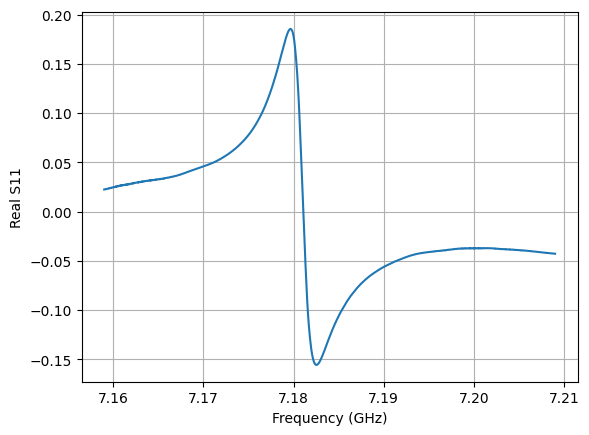

In [50]:
import time

n_points = 2001
f_center = 7.423578   * GHz
f_span = 50 * MHz
# f_center = 6 * GHz
# f_span = 8 * GHz
# x_array = np.linspace(f_center - f_span/2, f_center + f_span/2, n_points)
# x_array = np.array(kna.query_ascii_values("CALC1:MEAS1:X:VAL?"))
data = [x_array, y_data]
title = "Real part cavity"
# title = "room temp response"
# version = "Lossy_Ratio-6-1_17mm_Block1_B"
# for i in range(1):
#     save_data(data, f"ParampGain{i}.txt")
#     # time.sleep(10*60)
plt.plot(1e-9*x_array, y_data, label="In 8 Out 4")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Real S11")
# plt.ylabel("Logmag (dB)")
#plt.title(title + version)
# plt.legend()
plt.grid()
plt.show()


# plt.plot(x_array, real)
# plt.plot(x_array, imag)

# plt.grid()


In [51]:
data = [x_array, y_data]
path = r"D:\Experiments\2024-03-30 BF 3DTa09B, INDIQTa02I IITB_res and filters\\"
save_data(data, "Imag_-5dBm", path=path)
# save_data(data, "Logmag_2-10GHz", path=path)

In [47]:
def lorentzian(x,c,gam,a,y0):
    return y0 + (2*a/np.pi)*gam/(4*(x-c)**2 + gam**2)

def ext_BW(freq, ydata, plot=False):
    
    ymin = np.min(ydata)
    ymax = np.max(ydata)

     #initial guess
    left_index = np.where(ydata > 0.5*(ymax+ymin)) [0][0]    #FWHM
    right_index = np.where(ydata > 0.5*(ymax+ymin))[0][-1]   #FWHM
    BW_g = freq[right_index] - freq[left_index]
    wc_g = freq[np.argmax(ydata)]
    a_g = 0.5*np.pi*(ymax-ymin)*BW_g
    y0_g = ymin


    res, cov = curve_fit(lorentzian,freq,ydata,[wc_g, BW_g, a_g, y0_g])

    
    f0, bw = res[0], res[1]
    f0_err, bw_err = np.sqrt(cov[0,0]), np.sqrt(cov[1,1])

    a, y0 = res[2], res[3]
    a_err, y0_err = np.sqrt(cov[2,2]), np.sqrt(cov[3,3])

    H = 2*a/(np.pi*bw)
    H_err = H*(a_err/a + bw_err/bw) 
    y_xc = H + y0
    y_xc_err = H_err + y0_err
    
    r = (y0 - y_xc)/(y0 + y_xc)
    r_err = r*(y0_err + y_xc_err)*(1/(-y0 + y_xc) + 1/(-y0 - y_xc))

    kint = bw/(1+r)
    kext = bw*r/(1+r)

    kint_err = kint*(bw_err/bw + r_err/(r+1))
    kext_err = bw_err + kint_err
    
    Qint = f0/kint
    Qext = f0/kext
    
    Qint_err = Qint*(f0_err/f0 + kint_err/kint)
    Qext_err = Qext*(f0_err/f0 + kext_err/kext)

    
        
    f0 = np.round(f0*1e-9,10)
    f0_err = np.round(f0_err*1e-9,10)
    bw = np.round(bw*1e-9,10)
    bw_err = np.round(bw_err*1e-9,10)
    kint = np.round(kint*1e-9,10)
    kext = np.round(kext*1e-9,10)
    kint_err = np.round(kint_err*1e-9,10)
    kext_err = np.round(kext_err*1e-9,10)
    
    if plot:
        plt.plot(freq*1e-9, ydata, label = "Data")
        plt.plot(freq*1e-9, lorentzian(freq, res[0], res[1], res[2], res[3]), c = 'r',label = "Fit")
        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Measured ReS11")
        plt.grid()
        plt.legend()
        plt.show()
        print("Cavity Frequency = {0} GHz; Total Bandwidth = {1} MHz".format(np.round(f0,6), np.round(1e3*bw,3)))
        print("Internal Bandwidth = {0} MHz; External Bandwidth = {1} MHz".format(np.round(1e3*kint,3),np.round(1e3*kext,3)))
        
    out1 = [(f0, f0_err), (1e3*kint, 1e3*kint_err), (1e3*kext, 1e3*kext_err)]
    out2 = [(Qint, Qint_err), (Qext,Qext_err)]
    
    return out1, out2 ,res, np.sqrt(np.diag(cov))


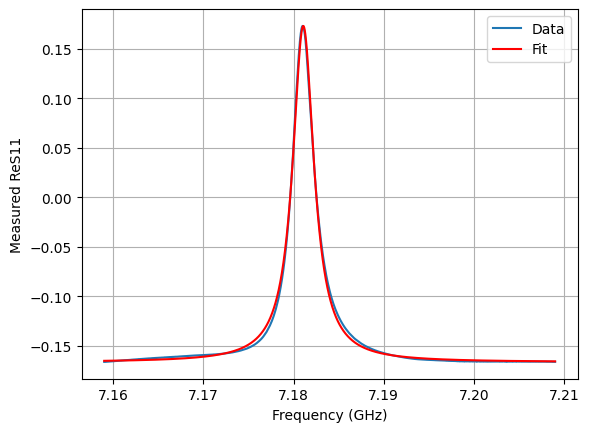

Cavity Frequency = 7.181077 GHz; Total Bandwidth = 2.856 MHz
Internal Bandwidth = -0.053 MHz; External Bandwidth = 2.91 MHz


In [48]:
# data = np.transpose(np.loadtxt(path+r'\Cavity_RT_response_with_qubit_chip.txt', dtype= str))
# data = np.transpose(data)
freq= [float(freq) for freq in data[0]]
ydata= [float(ydat) for ydat in data[1]]

freq = np.array(freq)
ydata = np.array(ydata)

meas_vals, q_vals, fit_param, fit_error = ext_BW(freq, ydata, plot=True)

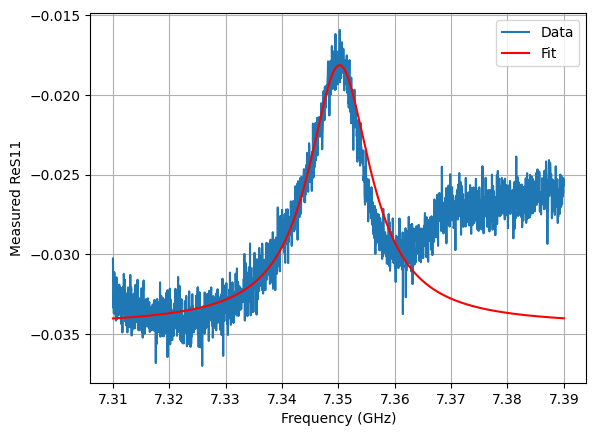

In [110]:
freq= [float(freq) for freq in data[0]]
ydata= [float(ydat) for ydat in data[1]]
freq = np.array(freq)
ydata = np.array(ydata)
res = fit_param
plt.plot(freq*1e-9, ydata, label = "Data")
plt.plot(freq*1e-9, lorentzian(freq, res[0], res[1], res[2], res[3]), c = 'r',label = "Fit")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Measured ReS11")
plt.grid()
plt.legend()
plt.show()